# Shot Map

Aggregate all shots from the 1. CFL 2025-26 season and plot them on a football pitch. Dot size represents xG value, colour represents outcome (goal / save / miss / block).

In [42]:
from pathlib import Path
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from mplsoccer import VerticalPitch
from PIL import Image

# ─── Path Configuration ──────────────────────────────────────────
RAW_MATCH_DIR  = Path('..') / 'data' / 'raw' / 'mt1cfl_2526' / 'raw_by_match'
DATA_DIR       = Path('..') / 'data' / 'processed'
FIGURES_DIR    = Path('..') / 'outputs' / 'figures'
FINAL_DIR      = Path('..') / 'outputs' / 'final_posts'
TEAM_LOGOS_DIR = DATA_DIR / 'team_logos'
FINAL_DIR.mkdir(parents=True, exist_ok=True)

# ─── Load All Shots ──────────────────────────────────────────────
all_shots = []
for match_dir in sorted(RAW_MATCH_DIR.iterdir()):
    if not match_dir.is_dir():
        continue
    shots_file = match_dir / 'match_shots.csv'
    if shots_file.exists():
        try:
            df = pd.read_csv(shots_file)
            if len(df) > 0:
                df['match_id'] = match_dir.name
                all_shots.append(df)
        except Exception:
            continue

shots = pd.concat(all_shots, ignore_index=True)

# ─── Load Metadata ───────────────────────────────────────────────
matches    = pd.read_csv(DATA_DIR / 'matches_metadata.csv')
matches['match_id'] = matches['match_id'].astype(str)
teams_meta = pd.read_csv(DATA_DIR / 'teams_metadata.csv')
standings  = pd.read_csv(DATA_DIR / 'league_standings.csv')

print(f'\u2705 Loaded {len(shots)} shots from {shots["match_id"].nunique()} matches')

✅ Loaded 2504 shots from 120 matches


In [43]:
# ─── Parse Coordinates & Player Info ─────────────────────────────
def parse_coords(coord_str):
    """Parse Sofascore coordinate dict string → (x, y)."""
    try:
        d = ast.literal_eval(coord_str)
        return float(d['x']), float(d['y'])
    except Exception:
        return np.nan, np.nan

def parse_player_info(player_str):
    """Parse Sofascore player dict string → (player_id, player_name, short_name)."""
    try:
        d = ast.literal_eval(player_str)
        return int(d['id']), d.get('name', ''), d.get('shortName', '')
    except Exception:
        return np.nan, '', ''

shots[['raw_x', 'raw_y']] = shots['playerCoordinates'].apply(
    lambda s: pd.Series(parse_coords(s))
)
shots[['player_id', 'player_name', 'player_short']] = shots['player'].apply(
    lambda s: pd.Series(parse_player_info(s))
)
shots = shots.dropna(subset=['raw_x', 'raw_y'])

# Sofascore coords: x is distance from goal line (0-100), y is lateral (0-100)
shots['pitch_x'] = shots['raw_y']  # lateral stays as-is (mapped to pitch width)
shots['pitch_y'] = 100 - shots['raw_x']  # invert so goal is at y=100

# Ensure xG is numeric
shots['xg'] = pd.to_numeric(shots['xg'], errors='coerce').fillna(0)
shots['isGoal'] = (shots['shotType'] == 'goal').astype(int)

# Assign team info
shots = shots.merge(
    matches[['match_id', 'homeTeam_id', 'homeTeam_name', 'awayTeam_id', 'awayTeam_name']],
    on='match_id', how='left'
)
shots['team_id'] = shots.apply(
    lambda r: r['homeTeam_id'] if r['isHome'] else r['awayTeam_id'], axis=1
)
shots['team_name'] = shots.apply(
    lambda r: r['homeTeam_name'] if r['isHome'] else r['awayTeam_name'], axis=1
)
shots = shots.merge(teams_meta[['team_id', 'short_name']], on='team_id', how='left')

# Filter out own goals
shots = shots[shots['situation'] != 'own-goal'].copy()

# ─── Find Top 3 xG Overperformers (from shot data, same as nb03) ─
# Aggregate goals and xG directly from shots — consistent with 03_xg_over_under
MIN_XG = 1.0  # Minimum total xG to qualify (same filter as nb03)

player_xg = (
    shots.groupby('player_id', as_index=False)
    .agg(goals=('isGoal', 'sum'), xG=('xg', 'sum'), total_shots=('xg', 'count'))
)
player_xg = player_xg[player_xg['xG'] >= MIN_XG].copy()
player_xg['overperformance'] = player_xg['goals'] - player_xg['xG']

# Add player names from shot data (first occurrence)
player_names = shots.drop_duplicates('player_id')[['player_id', 'player_name', 'player_short']]
player_xg = player_xg.merge(player_names, on='player_id', how='left')

# Add team info (team where player took most shots)
player_teams = (
    shots.groupby(['player_id', 'team_id', 'team_name'])
    .size().reset_index(name='n')
    .sort_values('n', ascending=False)
    .drop_duplicates('player_id')[['player_id', 'team_id', 'team_name']]
)
player_xg = player_xg.merge(player_teams, on='player_id', how='left')

top3 = player_xg.nlargest(3, 'overperformance')

TOP_PLAYERS = []
for _, row in top3.iterrows():
    TOP_PLAYERS.append({
        'player_id': int(row['player_id']),
        'name': row['player_name'],
        'short_name': row['player_short'],
        'team': row['team_name'],
        'team_id': int(row['team_id']),
        'goals': int(row['goals']),
        'xG': round(row['xG'], 2),
        'overperf': round(row['overperformance'], 2),
        'total_shots': int(row['total_shots']),
    })

print(f'✅ Parsed {len(shots)} shots (own goals excluded)')
print(f'\n🏆 Top 3 xG Overperformers (from shot data, min xG >= {MIN_XG}):')
for i, p in enumerate(TOP_PLAYERS, 1):
    print(f"   {i}. {p['name']} ({p['team']}) — {p['goals']} goals, {p['xG']} xG, +{p['overperf']}")

✅ Parsed 2494 shots (own goals excluded)

🏆 Top 3 xG Overperformers (from shot data, min xG >= 1.0):
   1. Asmir Kajević (FK Dečić Tuzi) — 6 goals, 3.23 xG, +2.77
   2. Andrija Ražnatović (FK Sutjeska Nikšić) — 6 goals, 3.23 xG, +2.77
   3. Armin Bošnjak (FK Arsenal Tivat) — 4 goals, 1.49 xG, +2.51


✅ Saved: shot_map_top3_overperformers.png


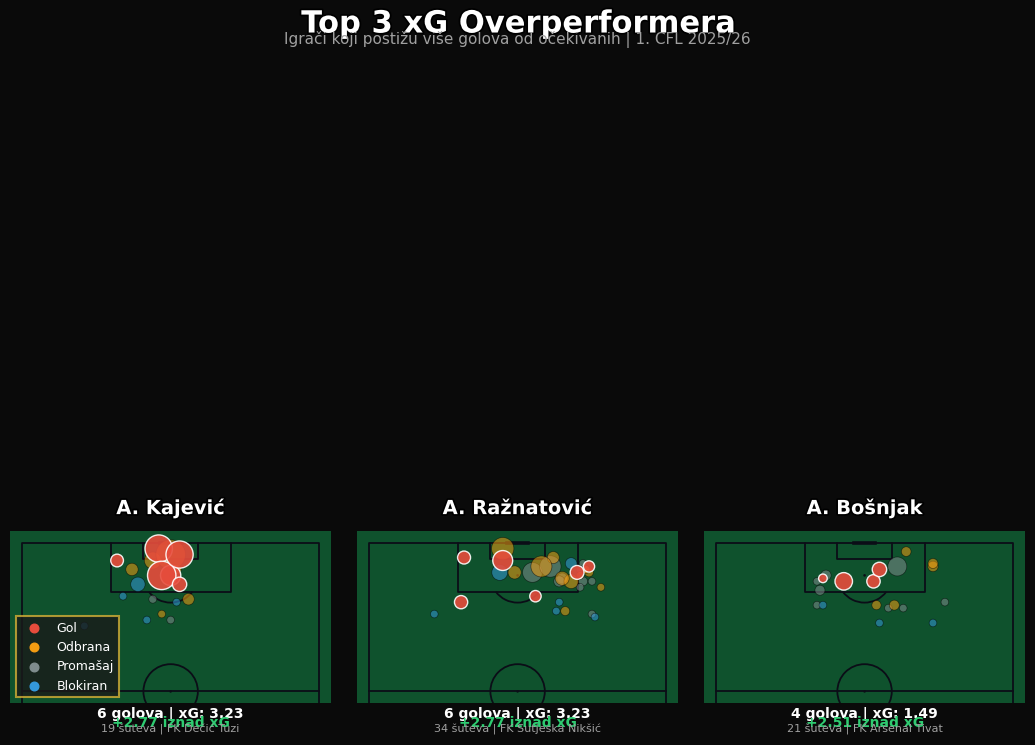

In [44]:
# ─── Color Constants ─────────────────────────────────────────────
BG_COLOR      = '#0a0a0a'
GOAL_COLOR    = '#e74c3c'   # Red for goals
SAVE_COLOR    = '#f39c12'   # Orange for saves
MISS_COLOR    = '#7f8c8d'   # Grey for misses
BLOCK_COLOR   = '#3498db'   # Blue for blocks
GOLD          = '#d4af37'
TEXT_WHITE    = '#FFFFFF'
TEXT_GREY     = '#A0A0A0'
PITCH_COLOR   = (15 / 255, 82 / 255, 45 / 255, 1.0)
LINE_COLOR    = '#0b0d17'

OUTCOME_COLORS = {
    'goal':  GOAL_COLOR,
    'save':  SAVE_COLOR,
    'miss':  MISS_COLOR,
    'block': BLOCK_COLOR,
}
OUTCOME_LABELS = {
    'goal':  'Gol',
    'save':  'Odbrana',
    'miss':  'Promašaj',
    'block': 'Blokiran',
}

# ─── Shot Maps for Top 3 xG Overperformers ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(10.8, 13.5), dpi=100)
fig.patch.set_facecolor(BG_COLOR)

pitch = VerticalPitch(
    pitch_type='custom',
    pitch_length=100, pitch_width=100,
    pitch_color=PITCH_COLOR,
    line_color=LINE_COLOR,
    line_zorder=3,
    linewidth=1.3,
    half=True,
)

for idx, (ax, p_info) in enumerate(zip(axes, TOP_PLAYERS)):
    ax.set_facecolor(BG_COLOR)
    pitch.draw(ax=ax)

    pid = p_info['player_id']
    player_shots = shots[(shots['player_id'] == pid) & (shots['pitch_y'] >= 50)]

    # Plot shots by outcome (goals last → on top)
    for outcome in ['miss', 'block', 'save', 'goal']:
        subset = player_shots[player_shots['shotType'] == outcome]
        if len(subset) == 0:
            continue
        sizes = np.clip(subset['xg'] * 800, 30, 500)
        alpha = 0.9 if outcome == 'goal' else 0.55
        zorder = 6 if outcome == 'goal' else 4
        edge_w = 1.0 if outcome == 'goal' else 0.5
        ax.scatter(
            subset['pitch_x'], subset['pitch_y'],
            s=sizes, c=OUTCOME_COLORS[outcome],
            edgecolors='white' if outcome == 'goal' else 'black',
            linewidth=edge_w,
            alpha=alpha, zorder=zorder,
        )

    # Player name & stats below pitch
    total_shots = len(player_shots)
    goals = (player_shots['shotType'] == 'goal').sum()
    total_xg = player_shots['xg'].sum()

    name_txt = ax.set_title(p_info['short_name'], fontsize=14, fontweight='bold',
                            color=TEXT_WHITE, pad=12)
    name_txt.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                               path_effects.Normal()])

    # Stats line under the pitch
    ax.text(0.5, -0.02, f"{goals} golova | xG: {total_xg:.2f}",
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            color=TEXT_WHITE, ha='center', va='top')
    ax.text(0.5, -0.07, f"+{p_info['overperf']:.2f} iznad xG",
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            color='#2ecc71', ha='center', va='top')
    ax.text(0.5, -0.12, f"{total_shots} šuteva | {p_info['team']}",
            transform=ax.transAxes, fontsize=8, color=TEXT_GREY,
            ha='center', va='top')

# Main title
suptitle = fig.suptitle('Top 3 xG Overperformera',
                         fontsize=22, fontweight='bold', color=TEXT_WHITE, y=0.96)
suptitle.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                           path_effects.Normal()])
fig.text(0.5, 0.935, 'Igrači koji postižu više golova od očekivanih | 1. CFL 2025/26',
         fontsize=11, color=TEXT_GREY, ha='center')

# Legend (place on leftmost axis)
for outcome in ['goal', 'save', 'miss', 'block']:
    axes[0].scatter([], [], s=60, c=OUTCOME_COLORS[outcome], label=OUTCOME_LABELS[outcome])
legend = axes[0].legend(loc='lower left', frameon=True, fancybox=False, fontsize=9,
                        edgecolor=GOLD, facecolor='#1a1a1a', labelcolor=TEXT_WHITE,
                        markerscale=0.8)
legend.get_frame().set_linewidth(1.5)

fig.subplots_adjust(left=0.03, right=0.97, top=0.90, bottom=0.12, wspace=0.08)
plt.savefig(FIGURES_DIR / 'shot_map_top3_overperformers.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: shot_map_top3_overperformers.png')
plt.show()

✅ Slide 1: Asmir Kajević → shot_map_slide_1.png (1080×1350px)
✅ Slide 2: Andrija Ražnatović → shot_map_slide_2.png (1080×1350px)
✅ Slide 3: Armin Bošnjak → shot_map_slide_3.png (1080×1350px)


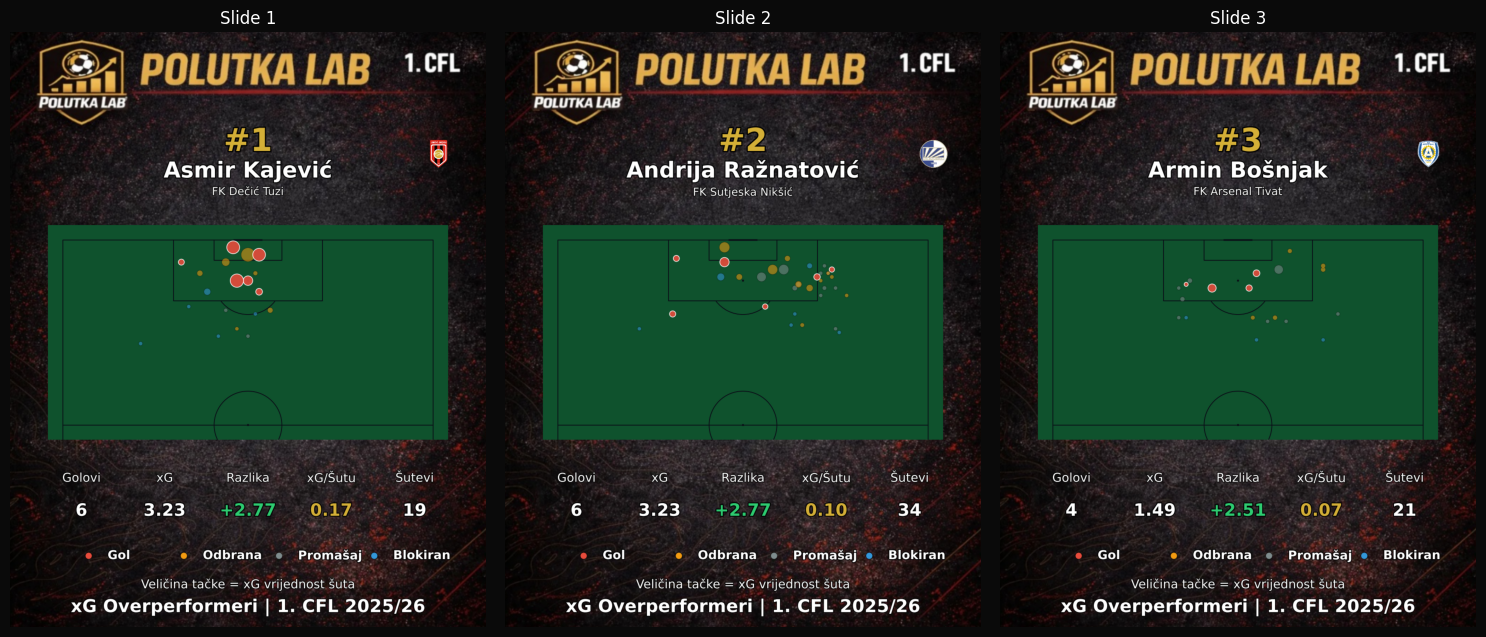

In [46]:
# ─── Instagram Carousel: 1 slide per player ─────────────────────
INSTAGRAM_SIZE = (1080, 1350)
BKG_PATH = FIGURES_DIR / 'background.png'

background = Image.open(BKG_PATH)
if background.size != INSTAGRAM_SIZE:
    background = background.resize(INSTAGRAM_SIZE, Image.Resampling.LANCZOS)
background_array = np.array(background)

pitch_inset = VerticalPitch(
    pitch_type='custom',
    pitch_length=100, pitch_width=100,
    pitch_color=PITCH_COLOR,
    line_color=LINE_COLOR,
    line_zorder=3,
    linewidth=1.3,
    half=True,
)

for i, p_info in enumerate(TOP_PLAYERS):
    fig = plt.figure(figsize=(10.8, 13.5), dpi=100)

    # Background
    ax_bg = fig.add_axes([0, 0, 1, 1], zorder=0)
    ax_bg.imshow(background_array, aspect='auto', extent=[0, 1, 0, 1])
    ax_bg.axis('off')

    # ── Header: rank + name + team logo ──────────────────────────
    # Rank pushed down to avoid logo overlap
    rank_txt = ax_bg.text(0.5, 0.84, f'#{i + 1}',
                          transform=fig.transFigure, fontsize=52, fontweight='bold',
                          color=GOLD, ha='center', va='top')
    rank_txt.set_path_effects([path_effects.Stroke(linewidth=4, foreground='black'),
                               path_effects.Normal()])

    # Player name — bigger
    name_txt = ax_bg.text(0.5, 0.785, p_info['name'],
                          transform=fig.transFigure, fontsize=36, fontweight='bold',
                          color=TEXT_WHITE, ha='center', va='top')
    name_txt.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'),
                               path_effects.Normal()])

    # Team name — white instead of grey
    team_txt = ax_bg.text(0.5, 0.74, p_info['team'],
                          transform=fig.transFigure, fontsize=18, color=TEXT_WHITE,
                          ha='center', va='top')
    team_txt.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                               path_effects.Normal()])

    # Team logo — bigger, right after player name
    logo_path = TEAM_LOGOS_DIR / f'{p_info["team_id"]}.png'
    if logo_path.exists():
        try:
            logo = plt.imread(str(logo_path))
            im = OffsetImage(logo, zoom=0.30)
            ab = AnnotationBbox(im, (0.90, 0.795),
                                xycoords=fig.transFigure, frameon=False, zorder=10)
            fig.add_artist(ab)
        except Exception:
            pass

    # ── Large pitch in the center ────────────────────────────────
    ax_pitch = fig.add_axes([0.08, 0.30, 0.84, 0.39])
    pitch_inset.draw(ax=ax_pitch)

    pid = p_info['player_id']
    player_shots = shots[(shots['player_id'] == pid) & (shots['pitch_y'] >= 50)]

    for outcome in ['miss', 'block', 'save', 'goal']:
        subset = player_shots[player_shots['shotType'] == outcome]
        if len(subset) == 0:
            continue
        sizes = np.clip(subset['xg'] * 900, 40, 550)
        alpha = 0.9 if outcome == 'goal' else 0.55
        zorder = 6 if outcome == 'goal' else 4
        edge_w = 1.2 if outcome == 'goal' else 0.5
        ax_pitch.scatter(
            subset['pitch_x'], subset['pitch_y'],
            s=sizes, c=OUTCOME_COLORS[outcome],
            edgecolors='white' if outcome == 'goal' else 'black',
            linewidth=edge_w, alpha=alpha, zorder=zorder,
        )

    # ── Stats bar below the pitch ────────────────────────────────
    xg_per_shot = p_info['xG'] / p_info['total_shots'] if p_info['total_shots'] > 0 else 0
    stat_items = [
        ('Golovi', str(p_info['goals']), TEXT_WHITE),
        ('xG', f"{p_info['xG']:.2f}", TEXT_WHITE),
        ('Razlika', f"+{p_info['overperf']:.2f}", '#2ecc71'),
        ('xG/Šutu', f"{xg_per_shot:.2f}", GOLD),
        ('Šutevi', str(p_info['total_shots']), TEXT_WHITE),
    ]
    stats_y_label = 0.25
    stats_y_val   = 0.195
    n_stats = len(stat_items)
    stats_total_width = 0.70
    stats_start = 0.5 - stats_total_width / 2
    stats_spacing = stats_total_width / (n_stats - 1)

    for j, (label, val, val_color) in enumerate(stat_items):
        sx = stats_start + j * stats_spacing
        # Labels — white instead of grey, bigger
        lbl = ax_bg.text(sx, stats_y_label, label,
                         transform=fig.transFigure, fontsize=20, color=TEXT_WHITE,
                         ha='center', va='center')
        lbl.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                              path_effects.Normal()])
        # Values — bigger
        v = ax_bg.text(sx, stats_y_val, val,
                       transform=fig.transFigure, fontsize=28, fontweight='bold',
                       color=val_color, ha='center', va='center')
        v.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'),
                            path_effects.Normal()])

    # ── Legend at bottom ──────────────────────────────────────────
    legend_y = 0.12
    legend_items = [('Gol', GOAL_COLOR), ('Odbrana', SAVE_COLOR), ('Promašaj', MISS_COLOR), ('Blokiran', BLOCK_COLOR)]
    legend_spacing = 0.20
    total_lw = (len(legend_items) - 1) * legend_spacing
    lx_start = 0.5 - total_lw / 2
    for j, (lbl, col) in enumerate(legend_items):
        lx = lx_start + j * legend_spacing
        ax_bg.scatter(lx - 0.035, legend_y, s=120, c=col, transform=fig.transFigure,
                      edgecolors='black', linewidth=0.6, zorder=10, clip_on=False)
        ltxt = ax_bg.text(lx + 0.005, legend_y, lbl,
                          transform=fig.transFigure, fontsize=20, fontweight='bold',
                          color=TEXT_WHITE, va='center')
        ltxt.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                               path_effects.Normal()])

    # Footer
    ftxt1 = ax_bg.text(0.5, 0.065, 'Veličina tačke = xG vrijednost šuta',
               transform=fig.transFigure, fontsize=20, color=TEXT_WHITE, ha='center')
    ftxt1.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                            path_effects.Normal()])

    ftxt2 = ax_bg.text(0.5, 0.025, 'xG Overperformeri | 1. CFL 2025/26',
               transform=fig.transFigure, fontsize=29, fontweight='bold',
               color=TEXT_WHITE, ha='center')
    ftxt2.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                            path_effects.Normal()])

    # ── Save individual slide ────────────────────────────────────
    slide_path = FINAL_DIR / f'shot_map_slide_{i + 1}.png'
    fig.savefig(slide_path, dpi=100, format='png')
    plt.close(fig)

    img = Image.open(slide_path)
    w, h = img.size
    print(f'✅ Slide {i + 1}: {p_info["name"]} → {slide_path.name} ({w}×{h}px)')

# ── Preview all 3 slides ─────────────────────────────────────────
fig_preview, axes_preview = plt.subplots(1, 3, figsize=(15, 6.25))
for i in range(3):
    img = Image.open(FINAL_DIR / f'shot_map_slide_{i + 1}.png')
    axes_preview[i].imshow(img)
    axes_preview[i].axis('off')
    axes_preview[i].set_title(f'Slide {i + 1}', color='white', fontsize=12)
fig_preview.patch.set_facecolor('#0a0a0a')
fig_preview.tight_layout()
plt.show()